## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864)
## Semestre: Enero_Junio del 2026

# PRÁCTICA No. 24: Convulusiones

## Paso 1: Importar las librerías necesarias

In [3]:
import os 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

## Paso 2. Especificamos ruta y cargamos imagen

[[136 126 123 ... 180 187 170]
 [104 115 121 ... 176 181 183]
 [104 118 127 ... 175 178 193]
 ...
 [139 140 140 ... 118 115 139]
 [139 140 140 ... 124 122 142]
 [138 139 139 ... 120 105 131]]


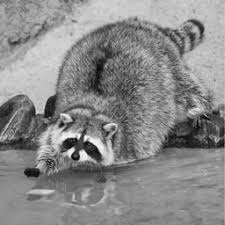

In [4]:
with Image.open("mapache.png", "r") as im:
    pixel_array = np.array(im, dtype=np.uint8)

print(pixel_array)
im

## Paso 3: Cargamos la imagen desde un archivo csv.

In [5]:
dt_mapache= pd.read_csv("mapache.csv", sep=";")
dt_mapache

,136,126,123,129,129.1,121,121.1,127,111,124,...,186.2,193.4,196.4,195.3,188.1,179.1,176,180.1,187.3,170.1
0,104,115,121,123,129,134,126,111,124,124,...,186,197,199,197,188,178,174,176,181,183
1,104,118,127,126,126,131,129,121,139,128,...,186,199,199,195,187,178,174,175,178,193
2,130,134,145,151,141,126,127,138,144,136,...,186,195,193,189,184,180,178,179,181,193
3,142,143,154,167,164,146,133,131,141,146,...,186,186,183,181,180,182,185,187,187,192
4,150,151,149,150,161,166,149,125,142,151,...,185,181,177,174,177,183,189,191,190,195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,139,140,140,141,142,143,143,144,144,144,...,129,128,129,129,128,126,121,117,114,143
220,139,140,140,141,142,143,143,144,144,144,...,134,132,132,131,129,124,119,113,110,138
221,139,140,140,141,142,143,143,144,144,144,...,135,131,131,132,130,127,122,118,115,139
222,139,140,140,141,142,143,143,144,144,144,...,130,128,129,131,131,130,127,124,122,142


### Paso 4: Convertir array a una imagen

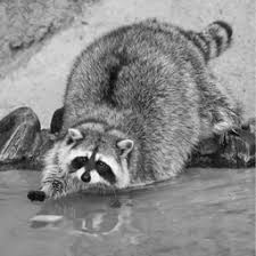

In [6]:
im = Image.fromarray(np.array(dt_mapache, dtype=np.uint8), mode="L")
im.resize((256, 256))

### Paso 5: Aplicamos filtros o nucleos con funcion Kernel() del modulo 

### Filtro de identididad no cambia imagen, devuelve exactamente la misma imgane despues de aplicar la convulusion, solo toma el pixel central e ignora vecinos


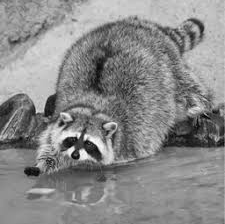

In [7]:
km =[ 0,0,0
    ,0,1,0
    ,0,0,0]

k= ImageFilter.Kernel(size=(3,3), kernel=km, scale=1)

im2 = im.filter(k)
im2

### Filtro de desenfoque se usa para suavizar una imagen reduciendo detalles finos y variaciones bruscas, toma y un pixel y lo remplaza por un promedio de sus vecinos

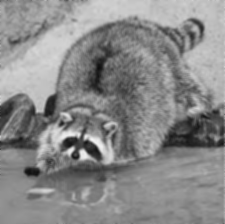

In [8]:
km =[ 1,1,1
    ,1,1,1
    ,1,1,1]

k= ImageFilter.Kernel(size=(3,3), kernel=km, scale=9)

im2 = im.filter(k)
im2

### Filtro de enfoque, se usa para resltar los detalles y hacer que una imagen se vea mas nitida, hace que las zonas donde hay cambios se vean mas marcadas

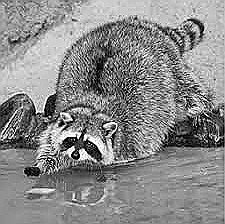

In [9]:
km =[ 0,-1,0
    ,-1,5,-1
    ,0,-1,0]

k= ImageFilter.Kernel(size=(3,3), kernel=km, scale=1)

im2 = im.filter(k)
im2

### Filtro de emboss, se usa para darle a la imagen un efecto 3D, resalta bordes y sombras para simular profunidad (luz y relieve)

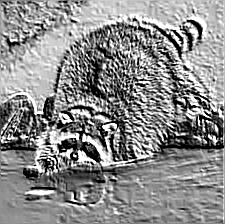

In [10]:
km =[ -2,-1,0
    ,-1,1,1
    ,0,1,2]

k= ImageFilter.Kernel(size=(3,3), kernel=km, scale=1)

im2 = im.filter(k)
im2

### Filtro de Laplace 

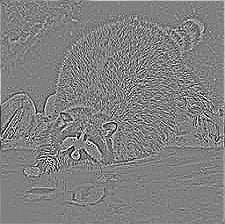

In [11]:
km = [0, 1, 0,
    1, -4, 1,
    0, 1, 0]

k = ImageFilter.Kernel(size=(3, 3), kernel=km, scale=1, offset=128)

im2 = im.filter(k)
im2

### Filtro de Prewitt

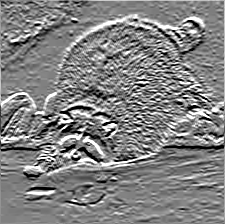

In [12]:
km = [-1, -1, -1,
    0, 0, 0,
    1, 1, 1]

k = ImageFilter.Kernel(size=(3, 3), kernel=km, scale=1, offset=128)

im2 = im.filter(k)
im2

### Filtro de Sobel 

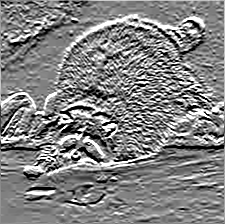

In [13]:
km = [-1, -2, -1,
    0, 0, 0,
    1, 2, 1]

k = ImageFilter.Kernel(size=(3, 3), kernel=km, scale=1, offset=128)

im2 = im.filter(k)
im2

### Filtro de Roberts

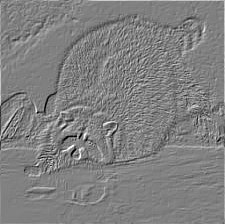

In [14]:
km = [0, 1, 0,
    -1, 0, 0,
    0, 0, 0]

k = ImageFilter.Kernel(size=(3, 3), kernel=km, scale=1, offset=128)

im2 = im.filter(k)
im2

## Conclusiones

### La implementación de filtros de convolución mediante kernels manuales permite comprender la base del procesamiento digital de imágenes y de las Capas Convolucionales en modelos de Deep Learning. Durante la práctica, se observó que:

### Extracción de Características: Filtros como Sobel y Prewitt son fundamentales para la detección de bordes, permitiendo segmentar formas y texturas al resaltar los gradientes de intensidad.

### Sensibilidad al Ruido: El filtro de Laplace, al ser una segunda derivada, es altamente sensible al ruido, lo que demuestra la necesidad de pre-procesamientos (como el suavizado Gaussiano) en aplicaciones de visión artificial.

### Visualización y Offset: Se identificó que la naturaleza de los filtros de paso alto genera valores cercanos a cero o negativos. El uso de un offset es una técnica crucial para la interpretación visual, permitiendo que la información no se pierda en la oscuridad del espectro de color y facilitando el análisis de la respuesta del filtro.

## Referencias 

### Pillow (PIL) Documentation:
### Pillow Core Team. (2024). ImageFilter Module - Kernel Class. Recuperado de https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html

### Fundamentos de Procesamiento de Imágenes:
Gonzalez, R. C., & Woods, R. E. (2018). Digital Image Processing (4th ed.). Pearson.

### Algoritmos de Detección de Bordes:
Sobel, I. (2014). An Isotropic 3x3 Image Gradient Operator. Presentation at Stanford Artificial Intelligence Project.

### Relación con Computación e Interfaces:
Szeliski, R. (2022). Computer Vision: Algorithms and Applications (2nd ed.). Springer Nature.